In [21]:
import data_generator as data
import seaborn as sns
import matplotlib.pyplot as plt
import pickle #saving Python objects to disk (binary).
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#import data_generator as data
import data_generator_update as data2
from acceptance_loop import AcceptanceLoop
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from Evaluation import Metric, AUC, BS, PAUC, ABR, Evaluation, bayesianMetric
from reject_inference import RejectInference, BiasAwareSelfLearning
import random

In [22]:
# generate data
res = data2.DataGenerator2(

    n = 1000, #simulate 1000 rows.
    k_con = 10, #t10 continuous features
    k_bin = 1, #no binary features - the generator will create a dummy B1(doos/bad) column of ones internally.
    bad_ratio = 0.8,#80% labeled "BAD" by default
    #con_mean_bad_dif=[2,1], 
    con_mean_bad_dif=[-0.5, 1.0, 1.2, 0.0, 0.9, -0.2, 1.5, 0.4, 0.3, 0.8], #the continuous mean difference between GOOD and BAD for each of the 10 continuous features.
    con_nonlinear = 0, #no nonlinear transforms on continuous variables.
    #con_noise_var = 0.1, #low noise variance on continuous variables.
    con_var_bad_dif = 0, #the continuous variance difference between GOOD and BAD is 0.5 (so BAD variance = GOOD variance * 0.5). 
    # NOTE: SET CON_VAR_BAD_DIF != 0 can cause non SPD problem. See below for fix.
    covars= None,
    #covars = [[1, 0.2, 0.2, 1], [1, -0.2, -0.2, 1]], #specifies covariance matrices for the two continuous features for GOOD and BAD respectively.
    # bin_prob = 0.5, bin_mean_bad_dif = 0, bin_bad_ratio = 0.5,
    # bin_mean_con_dif = 0, bin_var_bad_dif = 0, bin_noise_var = 0.1,
    verbose = True, seed = 100,

    #stronger separation/overlap or stronger bias
    coef_scale = 0.3, # downscale coefs (was 1.0)-decrese if less bias
    noise_scale = 3.0, # increase more noise
    flip_frac = 0.05 # flip 5% of labels

)
res.generate()
res.data

Generating 10 continuous features with 1 binary features
Simulating (1000 x 11) data set
Generated dataset with n=1000, k_con=10, k_bin=1
BAD prevalence (approx): 0.7790 (target 0.8)
coef_scale=0.3, noise_scale=3.0, flip_frac=0.05


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,BAD,B1
0,-0.808253,0.714846,0.038370,1.088628,-1.420181,0.197736,-0.106308,0.017771,0.356441,-0.144743,GOOD,0
1,-2.136471,-2.074125,-0.347529,-1.062008,-0.096265,-0.540224,0.804800,-0.582082,1.355682,0.334792,BAD,1
2,0.002373,-0.320721,-0.128565,-0.289677,0.703500,-1.788519,0.968153,-1.373144,-0.894040,1.380540,BAD,1
3,-0.250655,-1.777357,-0.854612,1.298419,1.508474,0.139208,1.362794,0.844719,-0.797703,1.345659,BAD,0
4,1.154584,0.176556,0.398686,-0.764524,-0.651487,-1.338043,1.777836,-0.068021,-1.208961,0.746231,BAD,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.120135,-1.793506,0.119839,-0.072589,1.709383,0.538023,-0.610381,-0.100358,-1.126318,1.500887,BAD,0
996,-1.137097,-0.527128,1.053344,0.948474,1.789183,-0.967692,1.067674,-0.532244,1.998911,-1.719186,BAD,1
997,-0.270096,0.639681,-0.638430,1.004868,-0.427083,0.057936,1.431530,-0.647578,-0.646529,0.163673,BAD,1
998,0.868990,-1.025265,0.986593,0.578865,-0.974637,-1.214606,0.600417,0.644403,0.324925,0.602680,BAD,1


In [26]:
import importlib, sys
import MMD_test     # module name = filename without .py
importlib.reload(MMD_test)  # reload if you edit the file

<module 'MMD_test' from '/Users/meng.y/code/Information-System--Foundation-Models-for-Reject-Inference/MMD_test.py'>

In [27]:
# prepare feature matrix and groups
df = res.data.copy()
features = [c for c in df.columns if c.startswith('X')]   # X1..X10
from sklearn.preprocessing import StandardScaler
Xmat = StandardScaler().fit_transform(df[features].astype(float).values)

# GOOD vs BAD
df['BAD_num'] = df['BAD'].map({'GOOD':0,'BAD':1})
X_good = Xmat[df['BAD_num'] == 0]
X_bad  = Xmat[df['BAD_num'] == 1]

mmd2, gamma = MMD_test.mmd_rbf_unbiased(X_good, X_bad)
print("MMD^2 (GOOD vs BAD):", mmd2, " gamma:", gamma)

mmd2_obs, gamma, pval = MMD_test.mmd_permutation_test(X_good, X_bad, n_permutations=300, gamma=gamma, seed=0)
print("Permutation p-value:", pval)

MMD^2 (GOOD vs BAD): 0.0026717750045875954  gamma: 0.053327232914245924
Permutation p-value: 0.013289036544850499


MMD^2 between GOOD and BAD is 0.0027 with a permutation p-value ≈ 0.013, so there is a statistically significant multivariate difference between the two groups under the RBF kernel (median heuristic). The absolute magnitude is modest; I’ll next compare this MMD against Accepts vs Full and correlate MMD with TabPFN AUC to understand practical impact.

In [8]:
# Replace the old "top X1" acceptance cell with this one.

# extract initial population
init_population = res.data.copy()
# drop columns that are not part of the business-rule score
if 'B1' in init_population.columns:
    init_population = init_population.drop(columns=['B1'])

# keep BAD/GOOD for interpretability, but create an int column if you need it:
init_population['BAD_int'] = init_population['BAD'].map({'BAD': 1, 'GOOD': 0})

# business rule parameters
top_percent = 0.2  # accept the top 20% by weighted business score

# features and weights (user-specified)
features = ['X1', 'X2', 'X3', 'X4', 'X5']
weights = np.array([0.5, 0.3, 0.1, 0.05, 0.05], dtype=float)

# sanity check
if any(f not in init_population.columns for f in features):
    missing = [f for f in features if f not in init_population.columns]
    raise ValueError(f"Missing required features in init_population: {missing}")

# normalize weights so they sum to 1 (optional but recommended)
weights = weights / weights.sum()

# standardize the features (z-score) to put them on comparable scale
X = init_population[features].astype(float)
Xz = (X - X.mean()) / X.std(ddof=0)   # ddof=0 for population std; use ddof=1 for sample std if preferred

# compute weighted score
init_population['business_score'] = Xz.dot(weights)

# select top percent by score (same interface as your previous quantile logic)
threshold = init_population['business_score'].quantile(1 - top_percent)
accepts_ind = init_population.index[init_population['business_score'] >= threshold]

# Select rows for current accepts and rejects
init_accepts = init_population.loc[accepts_ind].copy()    # DataFrame of accepted applicants
init_rejects = init_population.drop(accepts_ind).copy()   # DataFrame of rejected applicants

# quick diagnostics
print(f"Total applicants: {len(init_population)}")
print(f"Accepted (top {top_percent*100:.0f}%): {len(init_accepts)} ({len(init_accepts)/len(init_population):.2%})")
print(f"Rejected: {len(init_rejects)}")
print("Business-score summary:")
print(init_population['business_score'].describe())

Total applicants: 1000
Accepted (top 20%): 200 (20.00%)
Rejected: 800
Business-score summary:
count    1.000000e+03
mean     1.332268e-18
std      5.986749e-01
min     -1.807249e+00
25%     -4.176116e-01
50%     -2.559828e-02
75%      3.789965e-01
max      2.095214e+00
Name: business_score, dtype: float64


In [5]:
if (init_accepts['BAD'] == 'BAD').sum() < 4:
    # Adjust indices to ensure at least 4 'BAD' cases, ensures downstream model training has enough BAD examples among accepts.
    # threshold = init_population['X1'].quantile(1 - top_percent)
    # accepts_ind = init_population.index[init_population['X1'] >= threshold].tolist()
    # main_part = accepts_ind[:len(accepts_ind) - 4]
    # first_four = list(init_population.index[:4])
    # accepts_ind = main_part + first_four

    top_indices = init_population.index[init_population['X1'] >= init_population['X1'].quantile(1 - top_percent)]
    accepts_ind = list(top_indices[:len(accepts_ind) - 4]) + list(init_population.index[:4])
    init_accepts = init_population.loc[accepts_ind]
    init_rejects = init_population.drop(accepts_ind)

    #

In [6]:
weights = weights / weights.sum()

# 1) compute business_score if not already present
if 'business_score' not in init_population.columns:
    # ensure feature presence and numeric type
    missing = [f for f in features if f not in init_population.columns]
    if missing:
        raise ValueError(f"Missing features needed for business_score: {missing}")

    X = init_population[features].astype(float).copy()
    Xz = (X - X.mean()) / X.std(ddof=0)              # z-score standardize features
    init_population['business_score'] = Xz.dot(weights)

    # recompute for accepts/rejects frames (so they have the same column)
    init_accepts = init_population.loc[init_accepts.index].copy()
    init_rejects = init_population.loc[init_rejects.index].copy()


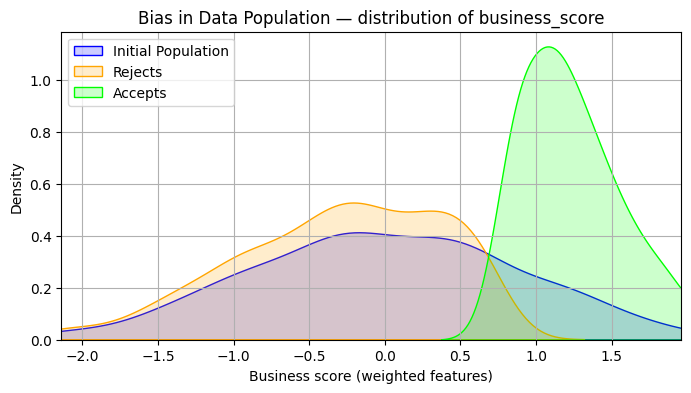

In [7]:
# 2) KDE plot on business_score
plt.figure(figsize=(8,4))
sns.kdeplot(init_population['business_score'], fill=True, color='blue', label='Initial Population', alpha=0.2)
sns.kdeplot(init_rejects['business_score'], fill=True, color='orange', label='Rejects', alpha=0.2)
sns.kdeplot(init_accepts['business_score'], fill=True, color='lime', label='Accepts', alpha=0.2)
plt.xlabel('Business score (weighted features)')
plt.title('Bias in Data Population — distribution of business_score')
plt.legend()
plt.grid(True)
plt.xlim(init_population['business_score'].quantile(0.01), init_population['business_score'].quantile(0.99))
plt.show()

In [8]:
# 3) Quick numeric diagnostics
print("Counts — initial / accepts / rejects:", len(init_population), len(init_accepts), len(init_rejects))
print("Mean business_score — initial / accepts / rejects:",
      init_population['business_score'].mean().round(3),
      init_accepts['business_score'].mean().round(3),
      init_rejects['business_score'].mean().round(3))

# Acceptance rate by true label (use numeric BAD column if available)
if 'BAD' in init_population.columns:
    # ensure numeric 0/1 for BAD for the diagnostics only
    try:
        bad_full = pd.to_numeric(init_population['BAD'], errors='coerce')
    except Exception:
        bad_full = init_population['BAD'].map({'GOOD':0, 'BAD':1}).astype(float)

    accept_mask = init_population.index.isin(init_accepts.index)
    accept_rate_by_label = {}
    for lab in [0,1]:
        mask = (bad_full == lab)
        if mask.sum() > 0:
            accept_rate_by_label[lab] = accept_mask[mask].mean()
        else:
            accept_rate_by_label[lab] = np.nan
    print("Acceptance rate by TRUE label (0=GOOD,1=BAD):", accept_rate_by_label)


Counts — initial / accepts / rejects: 1000 200 800
Mean business_score — initial / accepts / rejects: -0.0 1.269 -0.317
Acceptance rate by TRUE label (0=GOOD,1=BAD): {0: nan, 1: nan}


Compare means: a much higher mean for accepts vs full population confirms the shift quantitatively.

In [9]:
# 4) Acceptance fraction and BAD prevalence by score decile (shows how acceptance changes with score)
df_tmp = init_population[['business_score']].copy()
df_tmp['accept'] = df_tmp.index.isin(init_accepts.index).astype(int)
if 'BAD' in init_population.columns:
    df_tmp['BAD_true'] = bad_full
else:
    df_tmp['BAD_true'] = np.nan

df_tmp['decile'] = pd.qcut(df_tmp['business_score'], 10, labels=False, duplicates='drop')
decile_stats = df_tmp.groupby('decile').agg(
    n = ('accept','size'),
    accept_rate = ('accept','mean'),
    bad_rate = ('BAD_true','mean')
).sort_index(ascending=False)  # highest score first
print("\nDecile stats (highest score decile at top):")
display(decile_stats.head(10))


Decile stats (highest score decile at top):


,n,accept_rate,bad_rate
decile,,,
9,100,1.0,NaN
8,100,1.0,NaN
7,100,0.0,NaN
6,100,0.0,NaN
5,100,0.0,NaN
4,100,0.0,NaN
3,100,0.0,NaN
2,100,0.0,NaN
1,100,0.0,NaN


In [30]:
from MMD_test import mmd_rbf_unbiased, mmd_permutation_test
from sklearn.preprocessing import StandardScaler


A = init_accepts[features].astype(float).values
B = init_rejects[features].astype(float).values

# subsample if groups are large (speeds up MMD / permutation)
max_n = 1000
rng = np.random.RandomState(0)
if A.shape[0] > max_n:
    idx = rng.choice(A.shape[0], max_n, replace=False); A = A[idx]
if B.shape[0] > max_n:
    idx = rng.choice(B.shape[0], max_n, replace=False); B = B[idx]

pooled = np.vstack([A, B])
scaler = StandardScaler().fit(pooled)
A_s = scaler.transform(A)
B_s = scaler.transform(B)

#compute MMD^2 and gamma (unbiased estimator)
mmd2, gamma = mmd_rbf_unbiased(A_s, B_s)
print(f"MMD^2 (Accept vs Reject) = {mmd2:.6e}, gamma = {gamma:.6e}")

# permutation test (gives p-value)
mmd_obs, gamma, p_value = mmd_permutation_test(A_s, B_s, n_permutations=300, gamma=gamma, seed=0)
print(f"Permutation test p-value = {p_value:.4f}")



MMD^2 (Accept vs Reject) = 1.127013e-01, gamma = 5.332723e-02
Permutation test p-value = 0.0033


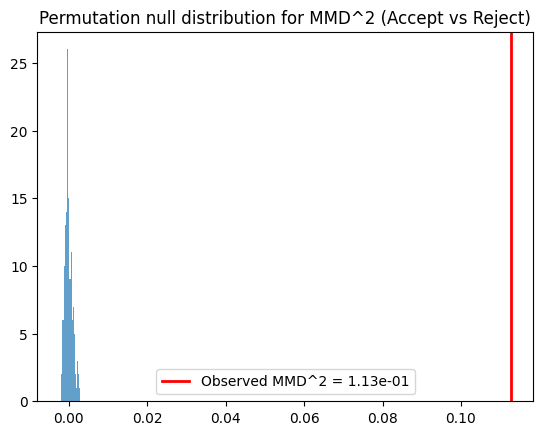

Interpretation:
- MMD^2 > 0 indicates multivariate difference (RBF kernel).
- Small p-value (e.g., < 0.05) means Accept and Reject are unlikely from same distribution under this kernel.
- Compare this MMD^2 to other scenarios (different generator params) to assess effect size.


In [31]:
# 6) compute permutation stats locally for plotting (useful to visualize null distribution)
# (mmd_permutation_test does not return perm_stats; compute them here if you want the histogram)
from numpy.random import RandomState
rng = RandomState(0)
Z = np.vstack([A_s, B_s])
n = A_s.shape[0]; m = B_s.shape[0]
labels = np.array([0]*n + [1]*m)
perm_stats = []
n_perm = 300
for i in range(n_perm):
    rng.shuffle(labels)
    Xp = Z[labels==0]
    Yp = Z[labels==1]
    # if shuffle changed sizes (rare), sample to original sizes
    if Xp.shape[0] != n:
        idx0 = np.where(labels==0)[0][:n]; idx1 = np.where(labels==1)[0][:m]
        Xp = Z[idx0]; Yp = Z[idx1]
    stat, _ = mmd_rbf_unbiased(Xp, Yp, gamma=gamma)
    perm_stats.append(stat)
perm_stats = np.array(perm_stats)

# 7) plot observed vs permuted (requires matplotlib)
import matplotlib.pyplot as plt
plt.hist(perm_stats, bins=40, alpha=0.7)
plt.axvline(mmd_obs, color='r', linewidth=2, label=f'Observed MMD^2 = {mmd_obs:.2e}')
plt.legend()
plt.title('Permutation null distribution for MMD^2 (Accept vs Reject)')
plt.show()

# 8) Quick interpretation helper
print("Interpretation:")
print("- MMD^2 > 0 indicates multivariate difference (RBF kernel).")
print("- Small p-value (e.g., < 0.05) means Accept and Reject are unlikely from same distribution under this kernel.")
print("- Compare this MMD^2 to other scenarios (different generator params) to assess effect size.")